In [6]:
import agrodesign
print(agrodesign)


<module 'agrodesign' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\__init__.py'>


In [7]:
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [8]:
import pandas as pd

df = pd.DataFrame({
    "Treatment": ["T1","T1","T2","T2","T3","T3"],
    "Yield": [10,12,15,14,18,17]
})

aov = Anova(df, response="Yield")
aov.crd(treatment="Treatment")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,21.166667,0.017024
Residual,3.0,3.000000,1.000000,NaN,NaN


In [10]:
aov.crd("Treatment")
aov.means("Treatment")
from agrodesign.mean_separation.dmrt import DMRT
DMRT(aov).test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [6]:
aov.means(treatment="Treatment")
lsd = LSD(aov)
lsd.test()

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [2]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

df = pd.DataFrame({
    "Block": ["B1","B1","B1","B2","B2","B2"],
    "Treatment": ["T1","T2","T3","T1","T2","T3"],
    "Yield": [10,14,18,12,15,17]
})

aov = Anova(df, response="Yield")

# RCBD ANOVA
aov.rcbd(treatment="Treatment", block="Block")


,DF,SS,MS,F,p-value
C(Treatment),2.0,42.333333,21.166667,18.142857,0.052239
C(Block),1.0,0.666667,0.666667,0.571429,0.528595
Residual,2.0,2.333333,1.166667,NaN,NaN


In [3]:
# Treatment means
aov.means("Treatment")


,Treatment,Mean,Replications
0,T1,11.0,2
1,T2,14.5,2
2,T3,17.5,2


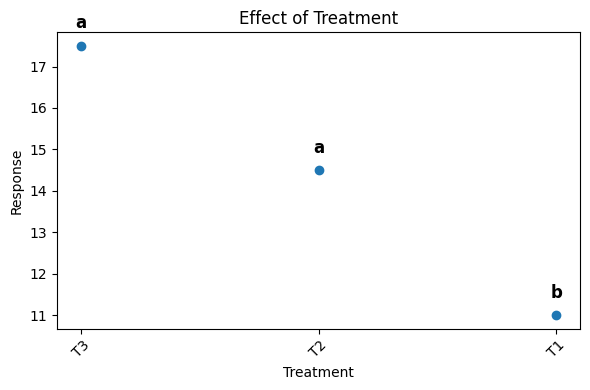

,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,b


In [5]:
from agrodesign.plots.effect_plot import effect_plot
effect_plot(aov, "Treatment", method="dmrt")


In [9]:
# LSD test
lsd = LSD(aov)
lsd.test()


,Treatment,Mean,Replications,Group
0,T3,17.5,2,a
1,T2,14.5,2,a
2,T1,11.0,2,a


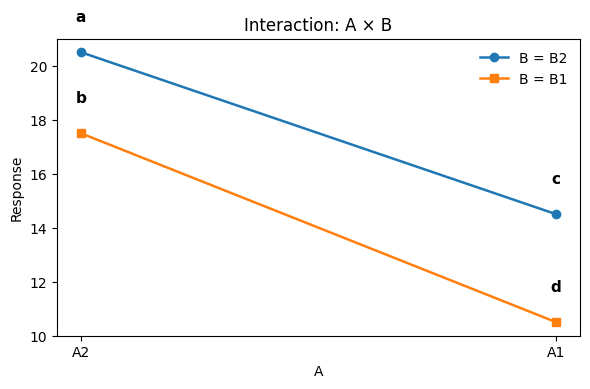

<Axes: title={'center': 'Interaction: A × B'}, xlabel='A', ylabel='Response'>

In [1]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.interaction_plot import interaction_plot

df = pd.DataFrame({
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"],
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"],
    "Yield": [10,11,14,15,18,17,20,21]
})

aov = Anova(df, response="Yield")

# factorial ANOVA
aov.factorial(["A","B"])
aov.factorial_means(["A","B"])

# interaction plot with letters
interaction_plot(aov, ["A","B"], method="dmrt")


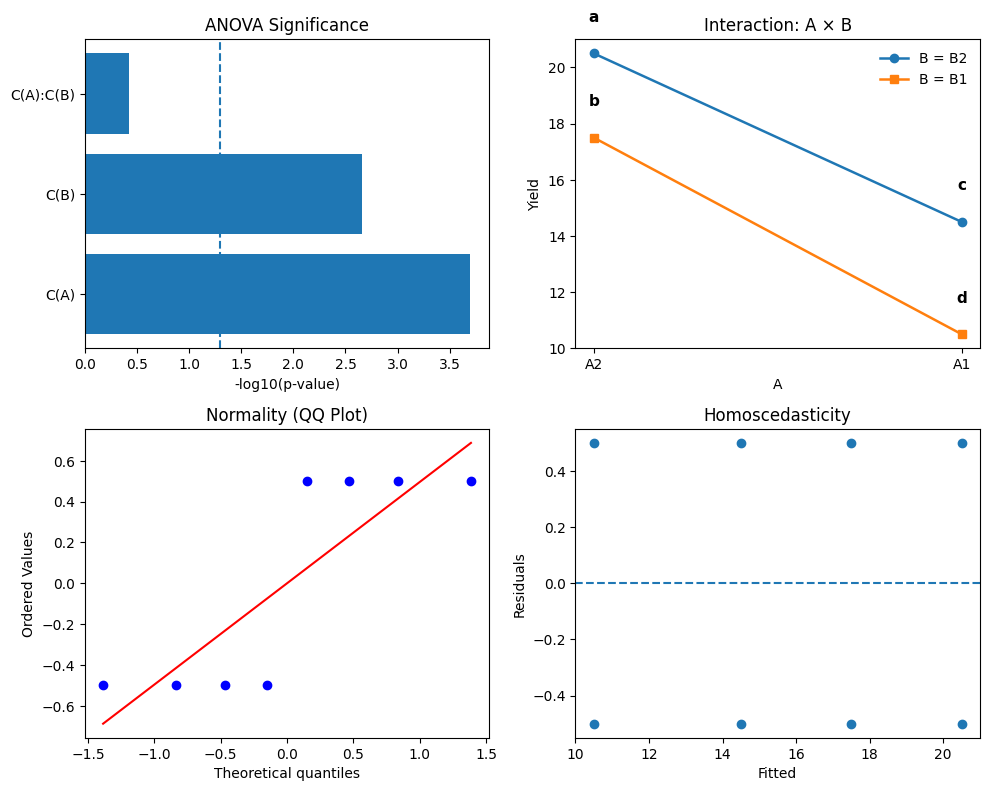

In [2]:
from agrodesign.plots.report_plot import report_plot
report_plot(aov, ["A","B"])


In [6]:
aov.factorial_means("A")

from agrodesign.mean_separation.lsd import LSD
lsd_A = LSD(aov)
lsd_A.test()


,A,Mean,Replications,Group
0,A2,19.0,4,a
1,A1,12.5,4,b


In [4]:
from agrodesign.analysis.assumptions import Assumptions

assump = Assumptions(aov)

# Normality
assump.shapiro_test()


{'Test': 'Shapiro-Wilk',
 'Statistic': np.float64(0.6646559035934576),
 'p-value': np.float64(0.0008917018985140214),
 'Normal': 'No'}

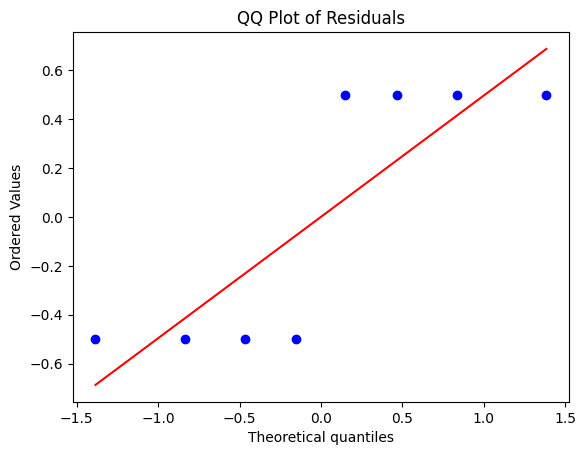

In [4]:
assump.qq_plot()


In [6]:
assump.bartlett_test("A")

{'Test': 'Bartlett',
 'Statistic': np.float64(0.8781123262779806),
 'p-value': np.float64(0.3487192197203338),
 'Homogeneous': 'Yes'}

In [12]:
df

,A,B,Yield
0,A1,B1,10
1,A1,B1,11
2,A1,B2,14
3,A1,B2,15
4,A2,B1,18
5,A2,B1,17
6,A2,B2,20
7,A2,B2,21


In [7]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey = TukeyHSD(aov, factor="A")
tukey.test()


,A,Mean,Group
0,A2,19.0,a
1,A1,12.5,b


In [8]:
from agrodesign.mean_separation.tukey import TukeyHSD

tukey_A = TukeyHSD(aov, factor=("A","B"))
tukey_A.test()


,A:B,Mean,Group
0,A2:B2,20.5,a
1,A2:B1,17.5,b
2,A1:B2,14.5,c
3,A1:B1,10.5,d


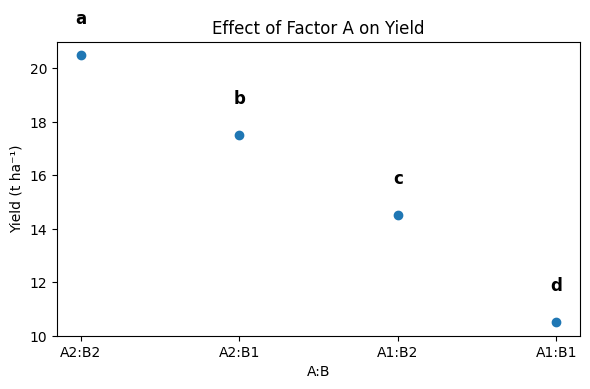

In [9]:
from agrodesign.mean_separation.tukey import TukeyHSD
from agrodesign.plots.mean_plot import mean_plot

tukey_A = TukeyHSD(aov, factor=("A","B"))
means_A = tukey_A.test()

mean_plot(
    means_df=means_A,
    factor="A:B",
    ylabel="Yield (t ha⁻¹)",
    title="Effect of Factor A on Yield",
    kind="point"
)


In [2]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD

In [4]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.mean_separation.lsd import LSD
from agrodesign.mean_separation.tukey import TukeyHSD
df = pd.DataFrame({
    "Rep": [1]*8 + [2]*8 + [3]*8,
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"] * 3,
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"] * 3,
    "C": ["C1","C2","C1","C2","C1","C2","C1","C2"] * 3,
    "Yield": [
        10,12,11,13,15,17,16,18,
        11,13,12,14,16,18,17,19,
        12,14,13,15,17,19,18,20
    ]
})



In [5]:
aov = Anova(df, response="Yield")
anova_table = aov.split_plot(
    whole_plot="A",
    sub_plot="B",
    block="Rep",
    sub_sub_plot="C"
)

anova_table


,DF,SS,MS,F,p-value
C(Rep),2.0,1.600000e+01,8.000000e+00,3.597448e+27,1.528488e-108
C(A),1.0,1.500000e+02,1.500000e+02,1.188422e+31,0.000000e+00
C(B),1.0,6.000000e+00,6.000000e+00,1.301042e+30,0.000000e+00
C(C),1.0,2.400000e+01,2.400000e+01,1.079234e+28,8.255723e-110
C(Rep):C(A),2.0,2.524355e-29,1.262177e-29,5.675772e-03,9.943443e-01
C(A):C(B),1.0,2.174298e-29,2.174298e-29,4.714756e+00,9.566562e-02
C(A):C(C),1.0,1.972152e-29,1.972152e-29,8.868393e-03,9.272883e-01
C(B):C(C),1.0,3.081488e-33,3.081488e-33,1.385686e-06,9.990896e-01
C(Rep):C(A):C(B),4.0,1.844675e-29,4.611687e-30,2.073788e-03,9.999893e-01
C(A):C(B):C(C),1.0,4.039908e-29,4.039908e-29,1.816670e-02,8.961122e-01


In [6]:
aov.factorial_means(["A", "B", "C"])


,A,B,C,Mean,Replications
0,A1,B1,C1,11.0,3
1,A1,B1,C2,13.0,3
2,A1,B2,C1,12.0,3
3,A1,B2,C2,14.0,3
4,A2,B1,C1,16.0,3
5,A2,B1,C2,18.0,3
6,A2,B2,C1,17.0,3
7,A2,B2,C2,19.0,3


In [ ]:
lsd_ABC = LSD(aov, effect="A:B:C")
lsd_ABC.test()

,A,B,C,Mean,Replications,Group
0,A2,B2,C2,19.0,3,a
1,A2,B1,C2,18.0,3,b
2,A2,B2,C1,17.0,3,c
3,A2,B1,C1,16.0,3,d
4,A1,B2,C2,14.0,3,e
5,A1,B1,C2,13.0,3,f
6,A1,B2,C1,12.0,3,g
7,A1,B1,C1,11.0,3,h


In [9]:
aov.factorial_means("A")

lsd_A = LSD(aov, effect="A")
lsd_A.test()

,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [10]:
tukey_B = TukeyHSD(aov, effect="B")
tukey_B.test()


,A,Mean,Replications,Group
0,A2,17.5,12,a
1,A1,12.5,12,b


In [12]:
aov.factorial_means(["A","C"])
LSD(aov, effect="A:C").test()

aov.factorial_means(["B","C"])
TukeyHSD(aov, effect="B:C").test()


,B,C,Mean,Replications,Group
0,B2,C2,16.5,6,a
1,B1,C2,15.5,6,b
2,B2,C1,14.5,6,c
3,B1,C1,13.5,6,d


In [2]:
import pandas as pd
from agrodesign.analysis.anova import Anova
from agrodesign.plots.boxplot_letters import boxplot_letters


In [3]:
df = pd.DataFrame({
    "Rep": [1,1,1,1, 2,2,2,2],
    "A": ["A1","A1","A1","A1","A2","A2","A2","A2"],
    "B": ["B1","B1","B2","B2","B1","B1","B2","B2"],
    "Yield": [10,12,11,13,15,17,16,18]
})


In [4]:
aov = Anova(df, response="Yield")
anova_table = aov.split_plot(
    whole_plot="A",
    sub_plot="B",
    block="Rep"
)

anova_table


,DF,SS,MS,F,p-value
C(Rep),1.0,50.000000,50.000000,25.000000,0.007490
C(A),1.0,0.333333,0.333333,0.453678,0.622639
C(B),1.0,3.266667,3.266667,1.633333,0.270369
C(Rep):C(A),1.0,0.734735,0.734735,0.367368,0.577155
C(A):C(B),1.0,1.665265,1.665265,0.832632,0.413134
Residual,4.0,8.000000,2.000000,NaN,NaN


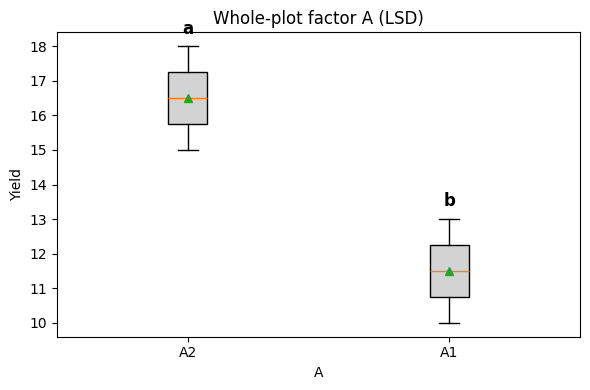

In [5]:
boxplot_letters(
    aov,
    factor="A",
    method="lsd",
    ylabel="Yield",
    title="Whole-plot factor A (LSD)"
)


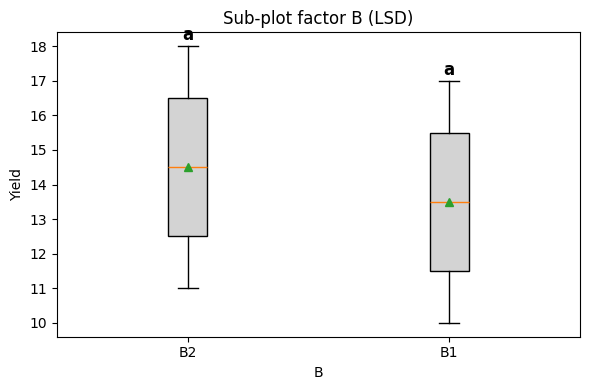

In [6]:
boxplot_letters(
    aov,
    factor="B",
    method="lsd",
    ylabel="Yield",
    title="Sub-plot factor B (LSD)"
)


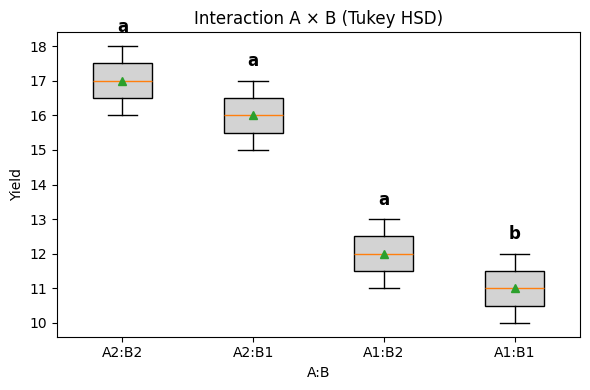

In [7]:
boxplot_letters(
    aov,
    factor=["A","B"],
    method="tukey",
    ylabel="Yield",
    title="Interaction A × B (Tukey HSD)"
)


In [1]:
from importlib import reload
import agrodesign.mixed.lmm as lmm
reload(lmm)

<module 'agrodesign.mixed.lmm' from 'D:\\Git Projects\\AGRODESIGN\\agrodesign\\mixed\\lmm.py'>

In [2]:
import pandas as pd

df = pd.DataFrame({
    "Block": [1,1,1,1, 2,2,2,2, 3,3,3,3, 4,4,4,4],
    "Treatment": [
        "T1","T2","T3","T4",
        "T1","T2","T3","T4",
        "T1","T2","T3","T4",
        "T1","T2","T3","T4"
    ],
    "Yield": [
        42, 50, 55, 60,
        40, 48, 54, 59,
        43, 49, 56, 61,
        41, 47, 53, 58
    ]
})

df


,Block,Treatment,Yield
0,1,T1,42
1,1,T2,50
2,1,T3,55
3,1,T4,60
4,2,T1,40
5,2,T2,48
6,2,T3,54
7,2,T4,59
8,3,T1,43
9,3,T2,49


In [3]:
from agrodesign.mixed import MixedModel
model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Treatment"],
    random=["Block"]
)

model.summary()


,Effect,Type,Variance,Std.Dev
0,Block,Random (Group),1.333322,1.154696
1,Residual,Error,0.333334,0.577351


In [5]:
from agrodesign.mixed import MixedModel

model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Treatment"],
    random=["Block"]
)

model.blup("Block")


D:\Git Projects\AGRODESIGN\agrodesign\mixed\lmm.py:159: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  values.append([level, float(val)])


,Block,BLUP
0,3,1.176470
1,1,0.705882
2,2,-0.705882
3,4,-1.176470


In [6]:
model.heritability("Treatment","Block")

0.9411758807096782

In [7]:
import pandas as pd

df = pd.DataFrame({
    "Location": ["L1"]*6 + ["L2"]*6,
    "Block":    [1,1,1,2,2,2]*2,
    "Genotype": ["G1","G2","G3"]*4,
    "Yield":    [42,51,48,44,53,50,38,47,46,41,49,47]
})


In [11]:
from agrodesign.mixed import MixedModel

model = MixedModel(df, response="Yield")

model.fit(
    fixed=["Genotype"],
    random=["Block"]
)

print(model.summary())
print(model.blup("Block"))
print(model.heritability("Genotype","Block"))


     Effect            Type  Variance   Std.Dev
0     Block  Random (Group)  1.260448  1.122697
1  Residual           Error  4.437492  2.106535
   Block      BLUP
0      2  0.630215
1      1 -0.630215
0.36228163347164744


D:\Git Projects\AGRODESIGN\agrodesign\mixed\lmm.py:159: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  values.append([level, float(val)])


In [1]:
import pandas as pd

In [2]:
df = pd.DataFrame({
"Env": ["E1"]*12 + ["E2"]*12,
"Block": [1,1,1,2,2,2]*4,
"Genotype": ["G1","G2","G3"]*8,
"Yield": [
42,51,48,44,53,50,43,52,49,45,54,51,
38,47,46,41,49,47,39,48,47,42,50,48
]})
df

,Env,Block,Genotype,Yield
0,E1,1,G1,42
1,E1,1,G2,51
2,E1,1,G3,48
3,E1,2,G1,44
4,E1,2,G2,53
5,E1,2,G3,50
6,E1,1,G1,43
7,E1,1,G2,52
8,E1,1,G3,49
9,E1,2,G1,45


In [3]:
from agrodesign.mixed.gxe import GxEModel

gxe = GxEModel(df, response="Yield")

gxe.fit(
    genotype="Genotype",
    environment="Env",
    block="Block"
)

gxe.summary()


d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
d:\Git Projects\AGRODESIGN\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

,Component,Variance
0,Block(Environment),0.000927
1,Genotype,8.850933
2,GxE,8.850933
3,Residual,0.499571


In [4]:
gxe.heritability()

np.float64(0.6604536970571756)

In [5]:
gxe.stability()

np.float64(8.850932536442736)

In [1]:
import pandas as pd
df = pd.DataFrame({
"Env": ["E1"]*12 + ["E2"]*12 + ["E3"]*12,
"Genotype": ["G1","G2","G3","G4"]*9,
"Yield": [
42,50,55,60, 44,52,57,63, 41,49,54,59,
38,46,52,58, 40,48,54,60, 37,45,51,56,
45,53,59,64, 46,55,61,66, 44,52,58,63
]})


In [2]:
from agrodesign.mixed.ammi import AMMI

ammi = AMMI(df, genotype="Genotype", environment="Env", response="Yield")

ammi.fit()


In [3]:
print(ammi.anova())

        Source  DF          SS          MS          F       p-value
0     Genotype   3  601.805556  200.601852  79.358974  1.341149e-12
1  Environment   2   91.129630   45.564815  18.025641  1.660609e-05
2          G×E   6    0.944444    0.157407   0.062271  9.988449e-01
3        IPCA1   4    0.803621    0.200905   0.079479  9.878862e-01
4        IPCA2   2    0.140824    0.070412   0.027855  9.725606e-01


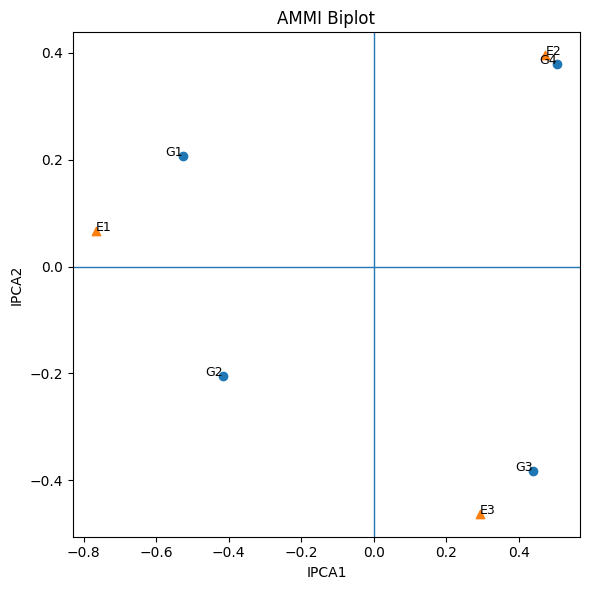

In [6]:
from agrodesign.mixed.ammi import AMMI
from agrodesign.plots.ammi_biplot import ammi_biplot

ammi = AMMI(df, genotype="Genotype", environment="Env", response="Yield")
ammi.fit()

ammi_biplot(ammi)


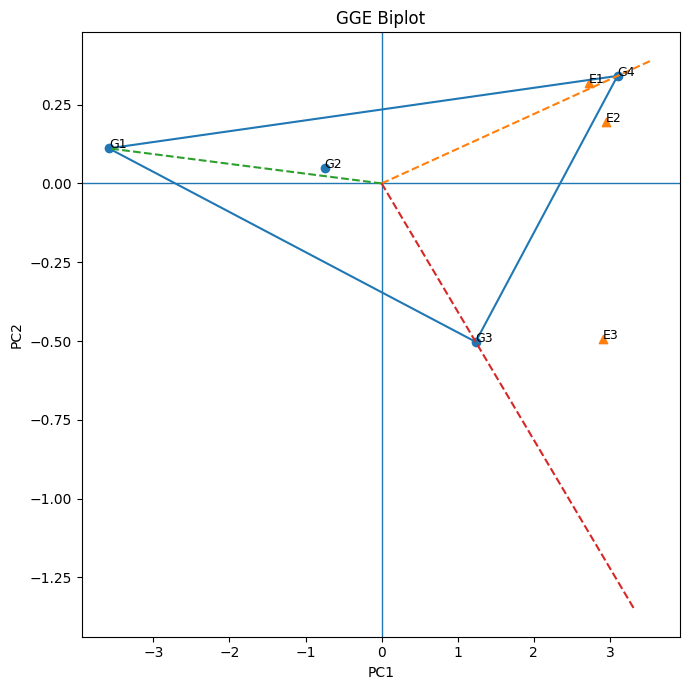

In [7]:
from agrodesign.plots.gge_biplot import gge_biplot

gge_biplot(df, genotype="Genotype", environment="Env", response="Yield")


In [3]:
from agrodesign.mixed.finlay_wilkinson import FinlayWilkinson

fw = FinlayWilkinson(df,
                     genotype="Genotype",
                     environment="Env",
                     response="Yield")

fw.fit()

,Genotype,MeanYield,Bi,S2di,R2
0,G1,41.888889,0.988417,0.260832,0.988417
1,G2,50.000000,1.037594,0.139098,0.994361
2,G3,55.666667,1.036375,0.196708,0.992025
3,G4,61.000000,0.937614,0.193739,0.990420


In [4]:
fw.classify()

,Genotype,MeanYield,Bi,S2di,R2,Adaptation
3,G4,61.000000,0.937614,0.193739,0.990420,Widely adapted
2,G3,55.666667,1.036375,0.196708,0.992025,Widely adapted
1,G2,50.000000,1.037594,0.139098,0.994361,Widely adapted
0,G1,41.888889,0.988417,0.260832,0.988417,Widely adapted


In [2]:
from agrodesign.mixed.eberhart_russell import EberhartRussell

er = EberhartRussell(df,
                     genotype="Genotype",
                     environment="Env",
                     response="Yield")

er.fit()

,Genotype,MeanYield,bi,S2di,t(bi=1),p(bi=1),R2
0,G1,41.888889,0.988417,0.260832,-0.108253,0.931351,0.988417
1,G2,50.000000,1.037594,0.139098,0.481125,0.714518,0.994361
2,G3,55.666667,1.036375,0.196708,0.391461,0.762462,0.992025
3,G4,61.000000,0.937614,0.193739,-0.676513,0.621346,0.990420


In [3]:
er.classify()

,Genotype,MeanYield,bi,S2di,t(bi=1),p(bi=1),R2,Adaptation
3,G4,61.000000,0.937614,0.193739,-0.676513,0.621346,0.990420,Widely adapted (stable)
2,G3,55.666667,1.036375,0.196708,0.391461,0.762462,0.992025,Unstable
1,G2,50.000000,1.037594,0.139098,0.481125,0.714518,0.994361,Widely adapted (stable)
0,G1,41.888889,0.988417,0.260832,-0.108253,0.931351,0.988417,Unstable


In [2]:
from agrodesign.mixed.ammi import AMMI
from agrodesign.mixed.finlay_wilkinson import FinlayWilkinson
from agrodesign.mixed.eberhart_russell import EberhartRussell
from agrodesign.mixed.stability_report import StabilityReport

ammi = AMMI(df,"Genotype","Env","Yield").fit()
fw = FinlayWilkinson(df,"Genotype","Env","Yield")
er = EberhartRussell(df,"Genotype","Env","Yield")

report = StabilityReport(ammi,fw,er)


In [3]:
report

In [4]:
report.build()

,MeanYield,ASV,Bi,S2di,R2,bi,t(bi=1),p(bi=1),Recommendation
Genotype,,,,,,,,,
G4,61.000000,1.263950,0.937614,0.193739,0.990420,0.937614,-0.676513,0.621346,Specific adaptation
G3,55.666667,1.113752,1.036375,0.196708,0.992025,1.036375,0.391461,0.762462,Specific adaptation
G2,50.000000,1.016209,1.037594,0.139098,0.994361,1.037594,0.481125,0.714518,Ideal genotype (widely adapted)
G1,41.888889,1.272883,0.988417,0.260832,0.988417,0.988417,-0.108253,0.931351,Specific adaptation


In [5]:
report.best()

MeanYield                        61.0
ASV                           1.26395
Bi                           0.937614
S2di                         0.193739
R2                            0.99042
bi                           0.937614
t(bi=1)                     -0.676513
p(bi=1)                      0.621346
Recommendation    Specific adaptation
Name: G4, dtype: object

In [4]:
print(ammi.stability())

         Genotype       ASV
Genotype                   
G2             G2  1.016209
G3             G3  1.113752
G4             G4  1.263950
G1             G1  1.272883


In [5]:
print(ammi.ranking())

          MeanYield  Stability  Rank
Genotype                            
G2        50.000000   1.016209   4.0
G3        55.666667   1.113752   4.0
G4        61.000000   1.263950   4.0
G1        41.888889   1.272883   8.0
